### Two observers, same accuracy — for different reasons
Edit the numbers marked `👈` and re-run.

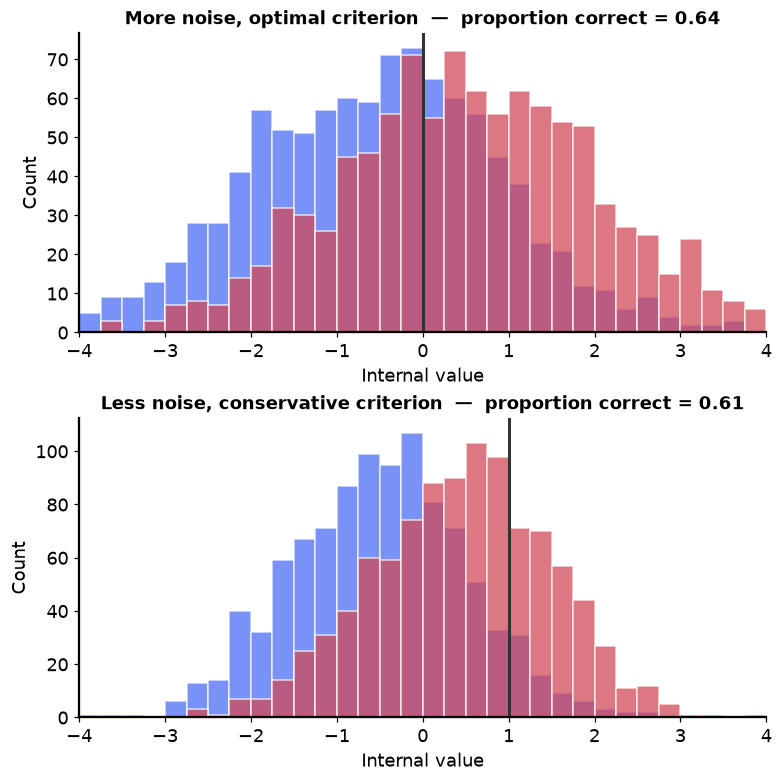

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # signal-absent (noise) trials
SIGNAL = "#d1495b"   # signal-present trials
CRIT   = "#333333"   # criterion / theory lines

ntrials         = 2000
psignal         = 0.5
signal_strength = 1       # 👈 how far the signal shifts the experience

rng = np.random.default_rng()
n_noise = round(ntrials * (1 - psignal))
bins = np.arange(-4, 4 + 0.25, 0.25)

# --- Observer 2: MORE noise (less sensitive), but an optimal criterion ---
noise_mean2, noise_sd2 = -0.5, 1.5     # 👈 bigger sd = more noise
noise2 = rng.standard_normal(ntrials) * noise_sd2 + noise_mean2
noise_samps2  = noise2[:n_noise]
signal_samps2 = noise2[n_noise:] + signal_strength
criterion2 = 0                          # optimal placement
pc2 = (np.sum(noise_samps2 <= criterion2) + np.sum(signal_samps2 > criterion2)) / ntrials

# --- Observer 1: LESS noise (sensitive), but a conservative criterion ---
noise_mean, noise_sd = -0.5, 1
noise = rng.standard_normal(ntrials) * noise_sd + noise_mean
noise_samps  = noise[:n_noise]
signal_samps = noise[n_noise:] + signal_strength
criterion = 1                           # 👈 too conservative (biased)
pc = (np.sum(noise_samps <= criterion) + np.sum(signal_samps > criterion)) / ntrials

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), constrained_layout=True)
for ax, nsamp, ssamp, crit, title in [
    (ax1, noise_samps2, signal_samps2, criterion2,
     f"More noise, optimal criterion  —  proportion correct = {pc2:.2g}"),
    (ax2, noise_samps,  signal_samps,  criterion,
     f"Less noise, conservative criterion  —  proportion correct = {pc:.2g}")]:
    ax.hist(nsamp, bins=bins, color=NOISE,  alpha=0.75, edgecolor="white")
    ax.hist(ssamp, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white")
    ax.axvline(crit, color=CRIT, lw=2)
    ax.set(xlim=(-4, 4), xlabel="Internal value", ylabel="Count", title=title)
plt.show()
